<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/huisoo_branch/04_titanic_sigakhwa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#분석환경 세팅
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#그리드 스타일 지정
sns.set_style("whitegrid")

In [4]:
#seaborn 내에 마련된 타이타닉 데이터를 이용
titanic = sns.load_dataset("titanic")

In [5]:
#앞 5개의 데이터를 확인
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
#데이터셋의 수치 확인
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#누락값을 없애고 다시 수치 확인
titanic.dropna().describe()

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


In [10]:
#분산 확인
titanic.var(numeric_only=True) #숫자 컬럼만 선택하도록 해 에러 방지

,0
survived,0.236772
pclass,0.699015
age,211.019125
sibsp,1.216043
parch,0.649728
fare,2469.436846
adult_male,0.239723
alone,0.239723


In [14]:
#평균절대편차 확인
#titanic.mad() ---> pandas 업데이트로 mad()메서드는 사라짐

# 따라서 수식의 조합으로 입력해야 함
df_numeric = titanic.select_dtypes(include=[np.number])
mad_values = (df_numeric - df_numeric.mean()).abs().mean()
mad_values

,0
survived,0.473013
pclass,0.761968
age,11.322944
sibsp,0.713780
parch,0.580742
fare,28.163692


In [15]:
#클래스별 인원수 확인하기
titanic.groupby('class').count()

/tmp/ipykernel_1777/424934974.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class').count()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,216,216,216,186,216,216,216,214,216,216,175,214,216,216
Second,184,184,184,173,184,184,184,184,184,184,16,184,184,184
Third,491,491,491,355,491,491,491,491,491,491,12,491,491,491


<Axes: xlabel='count', ylabel='alone'>

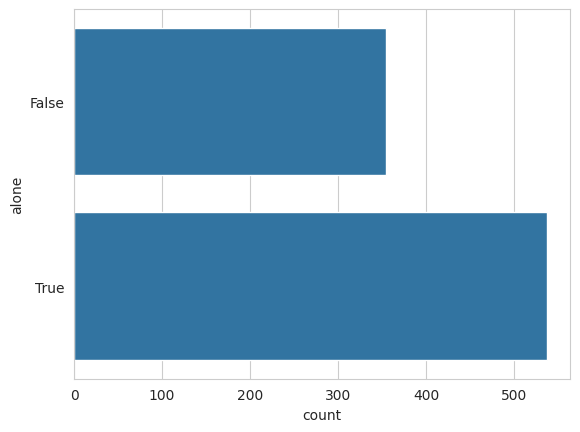

In [21]:
#클래스별 인원 수를 막대그래프로 나타내기
#sns.countplot(y='class',data=titanic) #등급별
#sns.countplot(y='sex',data=titanic) #성별별
#sns.countplot(y='alive',data=titanic) #생존여부별
sns.countplot(y='alone',data=titanic) #홀로 온 승객/아닌 승객

In [23]:
#등급별 요금의 평균
titanic.groupby('class')['fare'].median()

/tmp/ipykernel_1777/3434014833.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['fare'].median()


,fare
class,
First,60.2875
Second,14.2500
Third,8.0500


In [28]:
#등급별 생존자 수 확인
#query() 메서드: SQL 문장처럼 문자열 형태로 조건 입력해 필터링 수행
titanic.query("alive == 'yes'").groupby('class').count()

#왜 나이를 비롯한 몇몇 속성에서 동일 행의 다른 속성과 다른 수치가 나오는가?
# ==> 결측치 때문. 초반에 dropna() 하고 따로 할당을 안해서 데이터셋이 그대로다.

/tmp/ipykernel_1777/3641407794.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("alive == 'yes'").groupby('class').count()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,136,136,136,122,136,136,136,134,136,136,117,134,136,136
Second,87,87,87,83,87,87,87,87,87,87,13,87,87,87
Third,119,119,119,85,119,119,119,119,119,119,6,119,119,119


In [29]:
titanic.groupby('class')['age'].describe()

/tmp/ipykernel_1777/1607951913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['age'].describe()


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
First,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
Second,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
Third,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0


In [34]:
titanic.query("alive == 'yes'").groupby('class',observed = True).describe()
#observed = True : 실제로 존재하는 값들만 그룹핑(미래 버전 기본값이 F -> T로 변경)

survived                                    pclass       ... parch  \
          count mean  std  min  25%  50%  75%  max  count mean  ...   75%   
class                                                           ...         
First     136.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  136.0  1.0  ...   1.0   
Second     87.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   87.0  2.0  ...   1.0   
Third     119.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  119.0  3.0  ...   1.0   

              fare                                                    \
        max  count       mean        std      min       25%      50%   
class                                                                  
First   2.0  136.0  95.608029  85.286820  25.9292  50.98545  77.9583   
Second  3.0   87.0  22.055700  10.853502  10.5000  13.00000  21.0000   
Third   5.0  119.0  13.694887  10.692993   0.0000   7.77500   8.5167   

                              
               75%       max  
class                         
First   111.481225  512.3292  
Second   26.250000   65.0000  
Third    15.875000   56.4958  

[3 rows x 48 columns]

In [32]:
titanic.groupby('sex')['age'].aggregate(['min','median','max'])

,min,median,max
sex,,,
female,0.75,27.0,63.0
male,0.42,29.0,80.0


In [41]:
titanic.query("fare < 20").groupby('class',observed = True).median(numeric_only=True)
#numeric_only=True를 써서 True가 1.0로 처리되는 소소한 이슈

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,0.0,1.0,38.5,0.0,0.0,0.0000,1.0,1.0
Second,0.0,2.0,30.0,0.0,0.0,13.0000,1.0,1.0
Third,0.0,3.0,25.0,0.0,0.0,7.8958,1.0,1.0


In [43]:
titanic.groupby(['class','sex'],observed = True)['age'].mean().unstack()

#남자가 비교적 평균 나이가 많음

sex,female,male
class,,
First,34.611765,41.281386
Second,28.722973,30.740707
Third,21.750000,26.507589


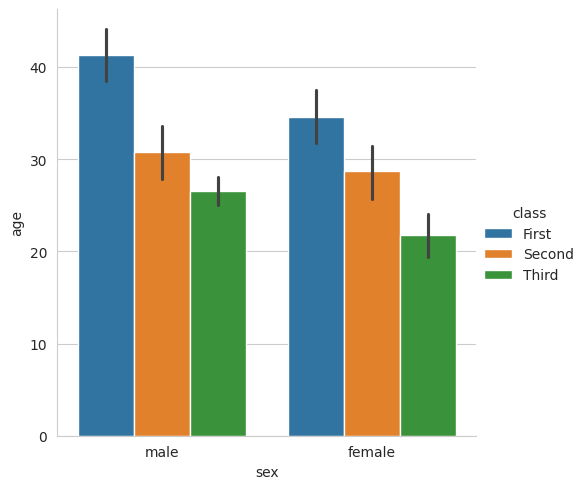

In [45]:
sns.catplot(x='sex',y='age',
            hue='class',kind='bar',
            data=titanic)

#hue:색상을 통해 그래프의 차원을 늘린 것
#kind:그래프 타입. 산점도, 막대, 박스 등등...


In [48]:
titanic.groupby(['class','sex'],observed = True)['fare'].mean().unstack()

#여성이 운임비를 더 많이 냄

sex,female,male
class,,
First,106.125798,67.226127
Second,21.970121,19.741782
Third,16.118810,12.661633


In [49]:
titanic.groupby(['class','who'],observed = True)['fare'].mean().unstack()

#운임비가 아이>여성>남성 순으로 비쌈

who,child,man,woman
class,,,
First,139.382633,65.951086,104.317995
Second,28.323905,19.054124,20.868624
Third,23.220190,11.340213,15.354351


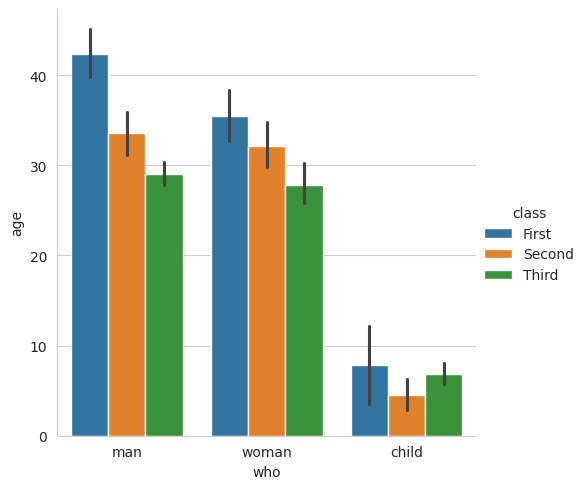

In [47]:
sns.catplot(x='who',y='age',
            hue='class',kind='bar',
            data=titanic)

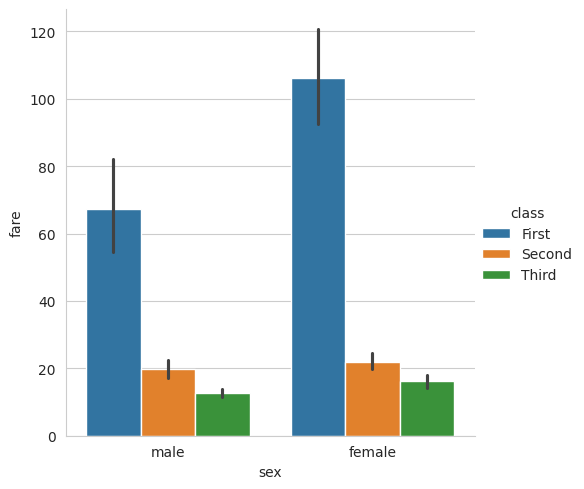

In [82]:
sns.catplot(x='sex',y='fare',
            hue='class',kind='bar',
            data=titanic)

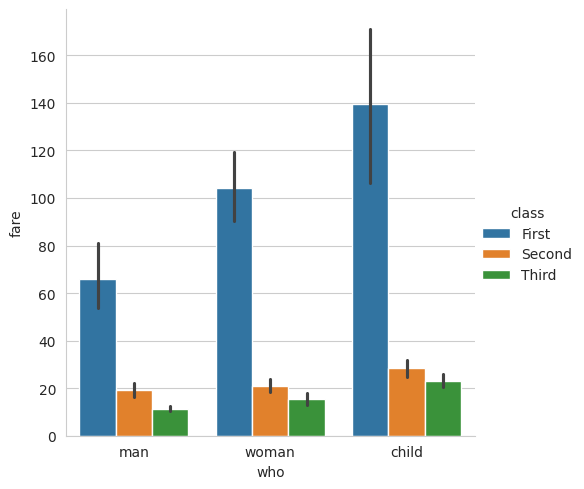

In [50]:
sns.catplot(x='who',y='fare',
            hue='class',kind='bar',
            data=titanic)

In [52]:
titanic.groupby(['class', 'sex'],observed = True)['survived'].mean().unstack()
#여성이 더 많이 생존

sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


In [56]:
titanic.pivot_table('survived', index = 'class', columns='who')

#pivot_table(): 엑셀의 피벗 테이블과 유사. groupby보다 직관적인 코드가 특징
#pivot_table(index='행 기준', columns='열 기준', values='계산할 값', aggfunc='계산 방법')

#3등급의 생존율이 현저히 낮으며, 2등급 아이들이 전부 생존한 희한한 관측값

/tmp/ipykernel_1777/3236330068.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index = 'class', columns='who')


who,child,man,woman
class,,,
First,0.833333,0.352941,0.978022
Second,1.000000,0.080808,0.909091
Third,0.431034,0.119122,0.491228


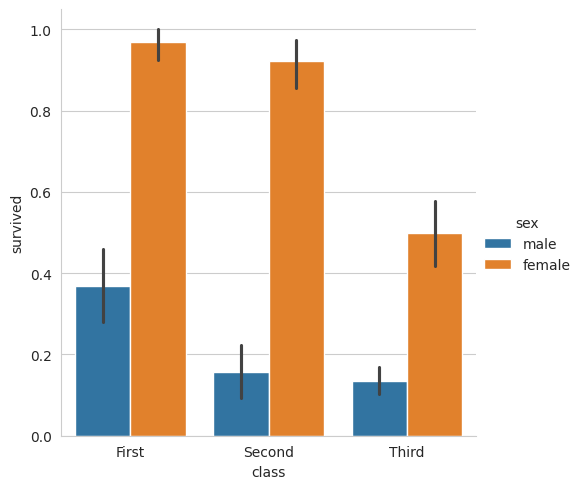

In [57]:
sns.catplot(x='class',y='survived',
            hue='sex',kind='bar',
            data=titanic)

#여성이 남성에 비해 많이 생존

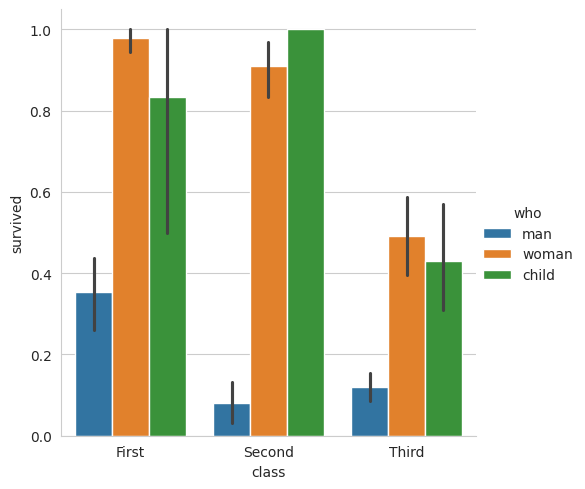

In [58]:
sns.catplot(x='class',y='survived',
            hue='who',kind='bar',
            data=titanic)

#아이들과 여성이 남성에 비해 월등히 높은 생존율을 보임

In [59]:
age = pd.cut(titanic['age'],[0,18,40,80])
#cut(): 연속형 숫자 데이터를 구간으로 나눠 범주형으로 나타내기 위한 메서드

titanic.pivot_table('survived',['sex',age],'class')

/tmp/ipykernel_1777/2075704991.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived',['sex',age],'class')


class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 40]  0.979167  0.914894  0.480000
       (40, 80]  0.961538  0.846154  0.111111
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 40]  0.478261  0.063492  0.146199
       (40, 80]  0.280000  0.095238  0.064516

In [62]:
fare = pd.qcut(titanic['fare'],3)
#qcut():지정한 개수만큼의 구간을 생성하는 매서드
titanic.pivot_table('survived',['who',age],[fare,'class'])


/tmp/ipykernel_1777/4063054740.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived',['who',age],[fare,'class'])


fare           (-0.001, 8.662]           (8.662, 26.0]                      \
class                    First     Third         First    Second     Third   
who   age                                                                    
child (0, 18]              NaN  0.666667           NaN  1.000000  0.703704   
man   (0, 18]              NaN  0.125000           NaN  0.000000  0.000000   
      (18, 40]             0.0  0.138462           NaN  0.078431  0.114286   
      (40, 80]             NaN  0.074074           0.0  0.111111  0.000000   
woman (0, 18]              NaN  0.666667           NaN  1.000000  0.333333   
      (18, 40]             NaN  0.550000           NaN  0.894737  0.461538   
      (40, 80]             NaN  0.000000           1.0  0.818182  0.250000   

fare           (26.0, 512.329]               
class                    First Second Third  
who   age                                    
child (0, 18]         0.833333    1.0  0.08  
man   (0, 18]         0.500000    0.0  0.00  
      (18, 40]        0.523810    0.0  0.50  
      (40, 80]        0.291667    0.0   NaN  
woman (0, 18]         1.000000    NaN  0.00  
      (18, 40]        0.979167    1.0  0.25  
      (40, 80]        0.958333    1.0  0.00

In [64]:
titanic.pivot_table('survived', index ='who', columns='class', margins=True)
#margins=True : 행과 열, 전체 값의 합을 보여주는 속성

/tmp/ipykernel_1777/3861620405.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index ='who', columns='class', margins=True)


class,First,Second,Third,All
who,,,,
child,0.833333,1.000000,0.431034,0.590361
man,0.352941,0.080808,0.119122,0.163873
woman,0.978022,0.909091,0.491228,0.756458
All,0.629630,0.472826,0.242363,0.383838


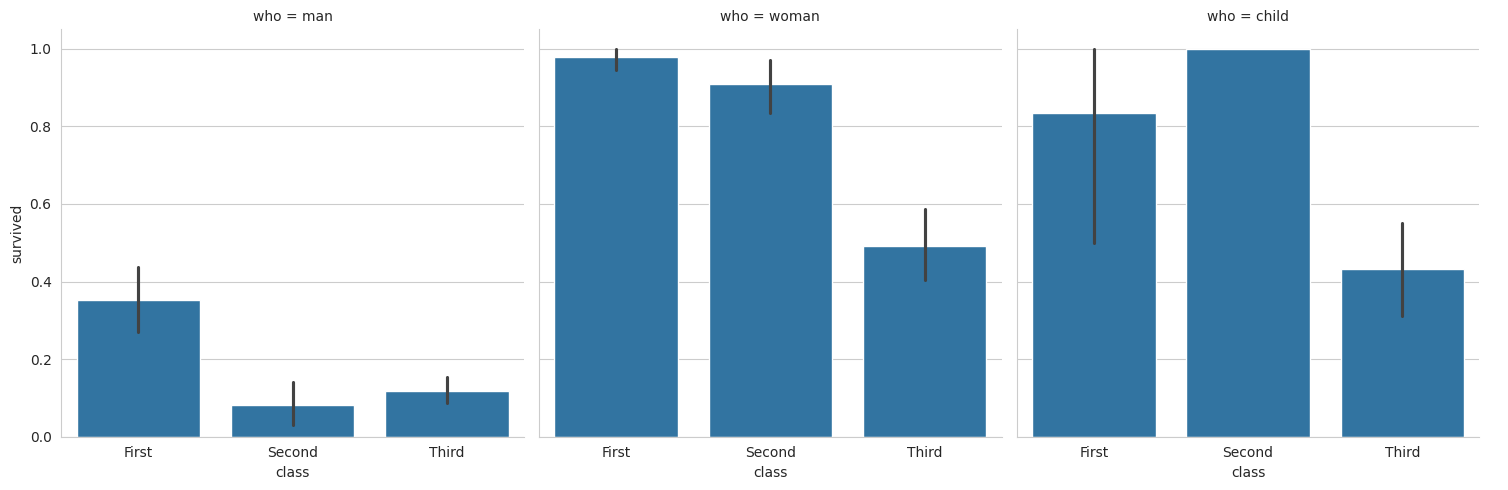

In [67]:
sns.catplot(x='class',y='survived',
            col='who',kind='bar',
            data=titanic)
#col:그래프를 열 방향으로 쪼개 여러개의 서브플롯을 반환

In [68]:
titanic.pivot_table('survived', index ='deck', columns='class', margins=True)

#클래스에 따라 deck 위치가 다르게 배치되어있음을 확인

/tmp/ipykernel_1777/3881880068.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index ='deck', columns='class', margins=True)


class,First,Second,Third,All
deck,,,,
A,0.466667,NaN,NaN,0.466667
B,0.744681,NaN,NaN,0.744681
C,0.593220,NaN,NaN,0.593220
D,0.758621,0.7500,NaN,0.757576
E,0.720000,0.7500,1.0,0.750000
F,NaN,0.8750,0.2,0.615385
G,NaN,NaN,0.5,0.500000
All,0.668571,0.8125,0.5,0.669951


<Axes: xlabel='count', ylabel='deck'>

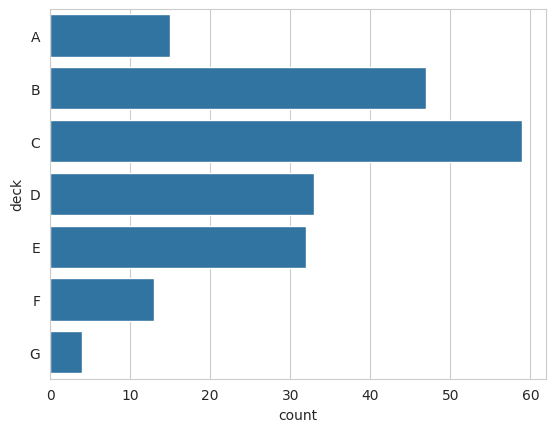

In [69]:
sns.countplot(y='deck', data = titanic)

<Axes: xlabel='count', ylabel='deck'>

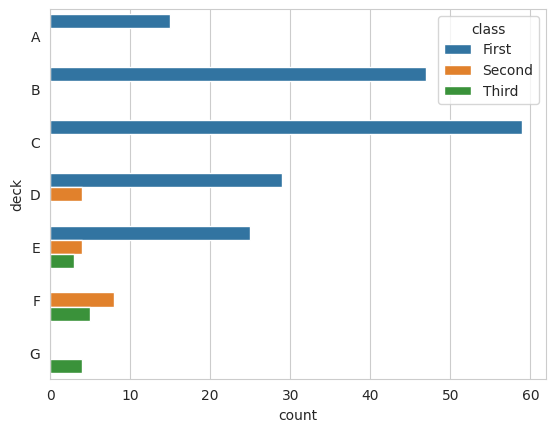

In [81]:
sns.countplot(y='deck', hue='class', data = titanic)

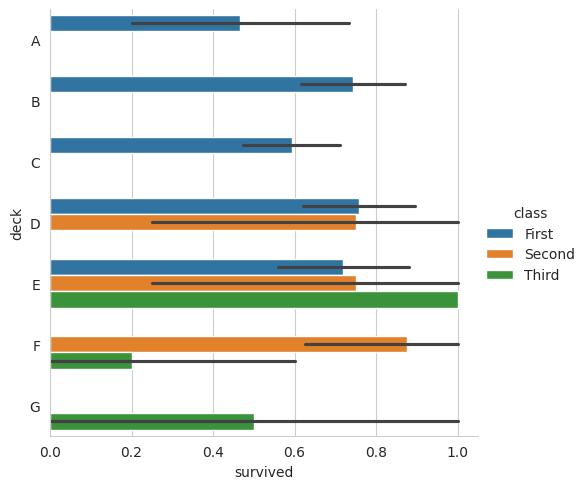

In [72]:
sns.catplot(x='survived',y='deck',
            hue='class',kind='bar',
            data=titanic)

#F,G쪽의 생존자가 비교적 적은 것을 확인

In [74]:
titanic.pivot_table('survived', index = 'embark_town', columns='class',margins=True)

/tmp/ipykernel_1777/482584483.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index = 'embark_town', columns='class',margins=True)


class,First,Second,Third,All
embark_town,,,,
Cherbourg,0.694118,0.529412,0.378788,0.553571
Queenstown,0.500000,0.666667,0.375000,0.389610
Southampton,0.582677,0.463415,0.189802,0.336957
All,0.626168,0.472826,0.242363,0.382452


<Axes: xlabel='count', ylabel='embark_town'>

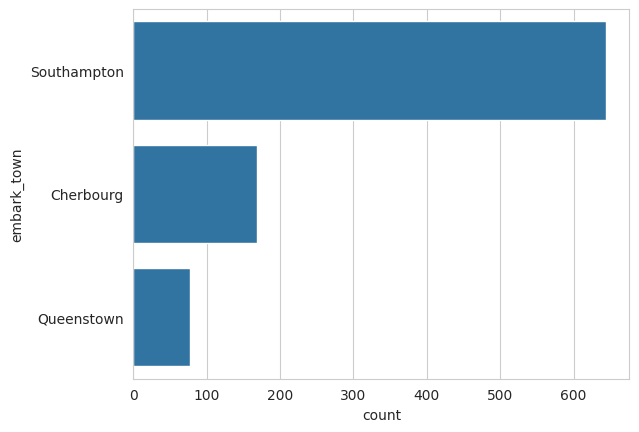

In [75]:
sns.countplot(y='embark_town', data = titanic)

#사우스햄튼에서 승선한 승객이 매우 많음

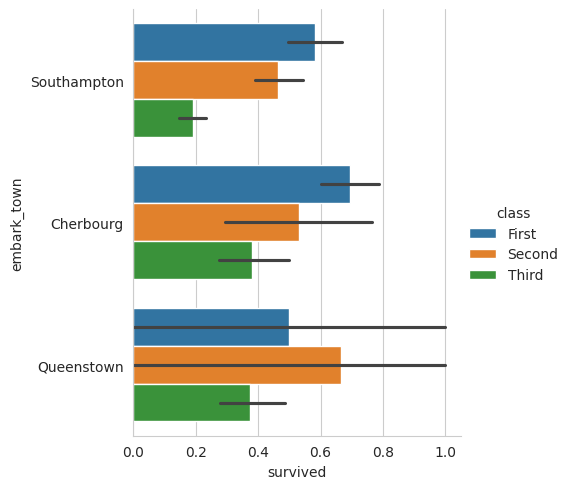

In [76]:
sns.catplot(x='survived',y='embark_town',
            hue='class',kind='bar',
            data=titanic)

#생존여부와 승선지는 큰 상관이 없어보임

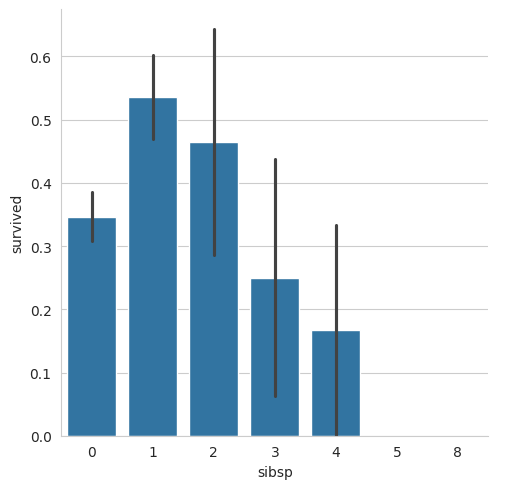

In [77]:
sns.catplot(x='sibsp',y='survived',
            kind='bar',data=titanic)

#형제가 한명 있는 사람들이 가장 높은 생존률을 보였음(인과여부는 불투명)

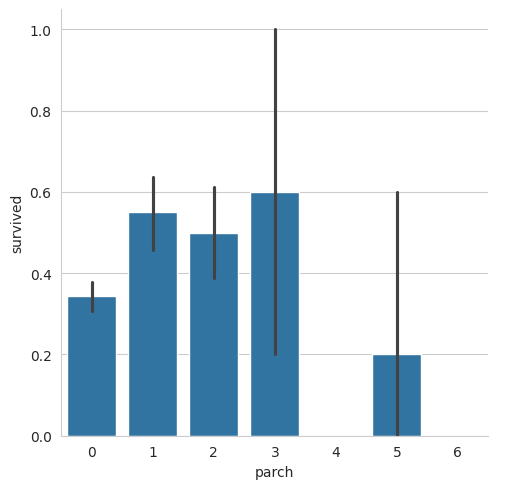

In [78]:
sns.catplot(x='parch',y='survived',
            kind='bar',data=titanic)

#아이가 없는 쪽은 아이가 5명인 쪽을 제외하고는 한명 이상인 쪽보다 생존율이 낮았음

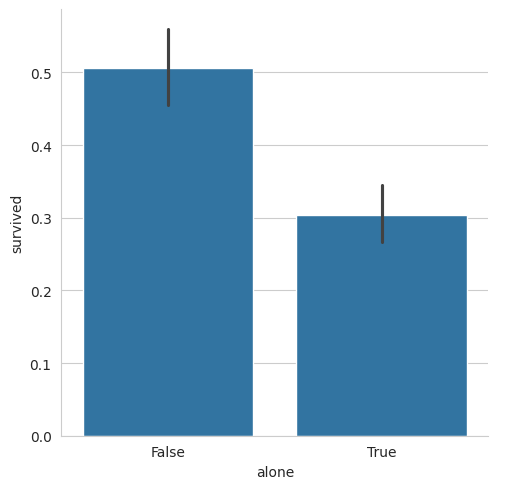

In [79]:
sns.catplot(x='alone',y='survived',
            kind='bar',data=titanic)

#동반자가 있는 쪽이 그렇지 않은 쪽보다 생존율이 높았음